In [2]:
import glob
from aind_ophys_utils.signal_utils import (
    nanmedian_filter,
    noise_std,
    percentile_filter,
)
from scipy.signal import savgol_filter
from typing import Tuple, Optional
from dff import *

In [12]:
%matplotlib inline

In [64]:
def extrapolate_trace(trace, size, edge_length=-1, deg="exp"):
    """Extrapolate trace edges using polynomial or exponential fitting.
    
    Parameters
    ----------
    trace : ndarray
        Input 1D trace (may contain NaN values)
    size : int
        Total padding size (will pad size//2 on each side)
    edge_length : int or None
        Number of points at each edge to fit polynomial to.
        Fits entire trace if set to -1.
    deg : int or "exp"
        Degree of polynomial for fitting, or "exp" for exponential
        
    Returns
    -------
    ndarray
        Padded trace with extrapolated edges
    """
    def _extrapolate_edge(data, x_pad, deg):
        """Helper to extrapolate a single edge."""
        valid = ~np.isnan(data)
        if valid.sum() <= (deg if isinstance(deg, int) else 2):
            return np.full(len(x_pad), np.nanmean(data))
        
        x_data = np.arange(len(data))[valid]
        y_data = data[valid]
        
        if deg == "exp":
            from scipy.optimize import curve_fit
            try:
                # Initial guess
                p0 = [np.nanmax(y_data) - (mi:=np.nanmin(y_data)), -0.001, mi]
                popt, _ = curve_fit(
                    lambda x, a, b, c: a * np.exp(b * x) + c,
                    x_data, y_data, p0=p0, maxfev=5000
                )
                return popt[0] * np.exp(popt[1] * x_pad) + popt[2]
            except:
                return np.full(len(x_pad), np.nanmean(data))
        else:
            p = np.polyfit(x_data, y_data, deg=deg)
            return np.polyval(p, x_pad)
    if edge_length == -1:
        edge_length = len(trace)
    else:
        edge_length = min(edge_length, len(trace))
    pad_size = size // 2
    
    pad_left = _extrapolate_edge(
        trace[:edge_length], 
        np.arange(-pad_size, 0),
        deg
    )
    pad_right = _extrapolate_edge(
        trace[-edge_length:],
        np.arange(edge_length, edge_length + pad_size),
        deg
    )
    
    return np.concatenate([pad_left, trace, pad_right])

In [65]:
def _dff_single_trace(
    F: np.ndarray,
    noise_method: Union[str, float],
    long_filter_length: float,
    short_filter_length: float,
    inactive_percentile: int,
    extrapolate_deg: Optional[int] = 2,
    edge_length: Optional[int] = -1,
) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Compute the "delta F over F" from the fluorescence trace.
    Uses configurable length median filters to compute baseline for
    baseline-subtraction and short timescale detrending.
    Returns the artifact-corrected and detrended dF/F, along with
    additional metadata for QA: the estimated baseline and
    the standard deviation of the noise.

    Parameters
    ----------
    F: np.ndarray
        1d numpy array of the neuropil-corrected fluorescence trace.
    noise_method: Union[str, float]
        Method for computing the noise, see ..signal_utils.noise_std.
        Choices: 'mad', 'fft', 'welch'
    long_filter_length: int
        Length of the percentile filter used to compute a rolling baseline.
    short_filter_length: int
        Length of the median filter to compute the rolling median-filtered
        signal, which is subtracted from the input `F` for noise_method='mad'.
    inactive_percentile: int
        Percentile value that defines the inactive frames used for
        calculating the baseline.
    extrapolate_deg: int
        Degree of polynomial for edge extrapolation. Default is 2.
        If 0 or None then no interpolation is performed.
    edge_length: int
        Number of points at each edge to fit polynomial to.
        Defaults to long_filter_length if set to None.
        Fits entire trace if set to -1.

    Returns
    -------
    dF/F: ndarray
        Baseline-corrected fluorescence dF/F.
    F0: ndarray
        Estimated baseline.
    noise_sd: float
        The estimated standard deviation of the noise in the input trace.
    """
    invalid = np.isnan(F).all()
    if invalid:
        return F, F, np.nan
    
    if isinstance(noise_method, str):
        noise_sd = noise_std(
            F, noise_method, filter_length=short_filter_length, device="cpu"
        )
    else:
        noise_sd = noise_method
    
    # Optionally extrapolate trace for filtering
    if extrapolate_deg:
        if edge_length is None:
            edge_length = long_filter_length
        F_padded = extrapolate_trace(
            F, 
            edge_length=edge_length, 
            size=long_filter_length,
            deg=extrapolate_deg
        )
        pad_size = long_filter_length // 2
    else:
        F_padded = F
        pad_size = 0
    
    # Create trace using inactive frames only, by replacing outliers with nan
    low_baseline = percentile_filter(
        F_padded, 
        inactive_percentile, 
        long_filter_length
    )
    
    # If extrapolated, trim back to original length
    if extrapolate_deg:
        low_baseline = low_baseline[pad_size:-pad_size]
    
    inactive_trace = F.copy()
    active_mask = F > (low_baseline + 3 * noise_sd)
    negative_mask = F < (low_baseline - 3 * noise_sd)
    inactive_trace[active_mask + negative_mask] = np.nan
    
    # Apply extrapolation for baseline filtering as well
    if extrapolate_deg:
        inactive_trace_padded = extrapolate_trace(
            inactive_trace,
            edge_length=edge_length,
            size=long_filter_length,
            deg=extrapolate_deg
        )
        baseline = nanmedian_filter(inactive_trace_padded, long_filter_length)
        baseline = baseline[pad_size:-pad_size]
    else:
        baseline = nanmedian_filter(inactive_trace, long_filter_length)
    
    # Calculate dF/F
    dff = (F - baseline) / np.maximum(baseline, noise_sd)
    return dff, baseline, noise_sd, F_padded, pad_size, active_mask

In [46]:
def get_valid_corrected_f(path):
    dr = path.split("/")[-1]
    data = []
    with h5py.File(f"{path}/{dr}_data.h5") as f:
        for k in f['planes'].keys():
            data.append(f[f'planes/{k}/corrected_f'][f[f'planes/{k}/valid_roi_inds'][:]])
    return data

In [47]:
dirs = glob.glob("/data/test-dataset-for-dff_multiplane-ophys_02/*/*")
dirs

['/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/804670',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/775682',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/782149',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753562',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/729088',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/758265',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753561',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/724567',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/755212',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/759075',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/726433',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/747443',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/757436',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/69

In [48]:
traces = get_valid_corrected_f(dirs[0])

In [69]:
[t.shape for t in traces]

[(56, 48374),
 (46, 48374),
 (73, 48374),
 (73, 48374),
 (62, 48374),
 (56, 48374),
 (41, 48374),
 (49, 48374),
 (59, 48403),
 (46, 48403),
 (71, 48403),
 (75, 48403),
 (65, 48403),
 (57, 48403),
 (39, 48403),
 (53, 48403),
 (57, 48427),
 (48, 48427),
 (67, 48427),
 (73, 48427),
 (65, 48427),
 (61, 48427),
 (41, 48427),
 (48, 48427),
 (55, 48390),
 (46, 48390),
 (65, 48390),
 (76, 48390),
 (63, 48390),
 (56, 48390),
 (40, 48390),
 (48, 48390),
 (60, 48373),
 (42, 48373),
 (65, 48373),
 (76, 48373),
 (66, 48373),
 (58, 48373),
 (40, 48373),
 (52, 48373),
 (58, 48366),
 (44, 48366),
 (66, 48366),
 (75, 48366),
 (61, 48366),
 (54, 48366),
 (42, 48366),
 (51, 48366)]

In [66]:
def fit_and_plot(
    trace,
    long_filter_length=int(30*60)//2*2+1,
    short_filter_length=int(30*3.333)//2*2+1,
    inactive_percentile=10,
    extrapolate_deg="exp",
    edge_length=-1,
):
    dff_old, F0_old = _dff_single_trace(
        trace, "mad", long_filter_length, short_filter_length, inactive_percentile, extrapolate_deg=0
    )[:2]
    dff, F0, noise_sd, F_padded, pad_size, active_mask = _dff_single_trace(
        trace, "mad", long_filter_length, short_filter_length, inactive_percentile, extrapolate_deg, edge_length
    )
    
    fig, ax = plt.subplots(2, 1, figsize=(15, 3), sharex=True)
    ax[0].plot(np.arange(len(F_padded)) - pad_size, F_padded, lw=.5, label="extrapolated data")
    ax[0].plot(F0_old, label="F$_0$ w/o extrapolation")
    ax[0].plot(F0, label="F$_0$ w/ extrapolation")
    for xmin, xmax in zip(np.where(np.diff(active_mask, prepend=0) == 1)[0] - .5,
                          np.where(np.diff(active_mask, append=0) == -1)[0] + .5):
        ax[0].axvspan(xmin, xmax, facecolor='red', alpha=0.3)
    ax[0].legend(ncol=3)
    ax[1].plot(dff_old, lw=1, c="C1", label="$\Delta$F/F w/o extrapolation")
    ax[1].plot(dff, lw=.3, c="C2", label="$\Delta$F/F w/ extrapolation")
    ax[1].legend(ncol=2)
    plt.xlim(-1.1*pad_size, len(trace)+1.1*pad_size);

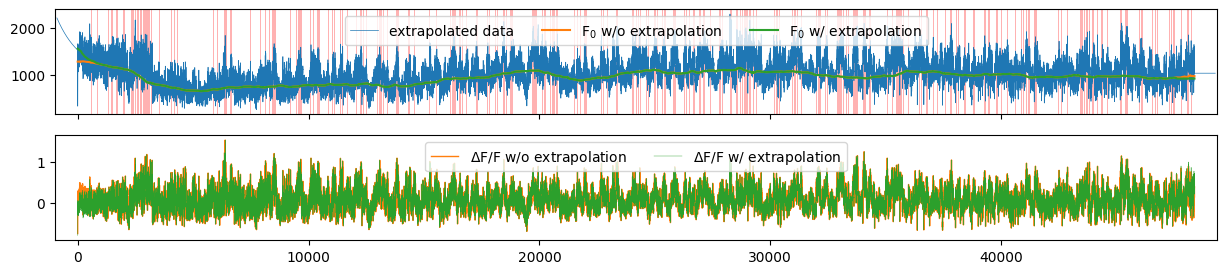

In [67]:
fit_and_plot(traces[0][0])

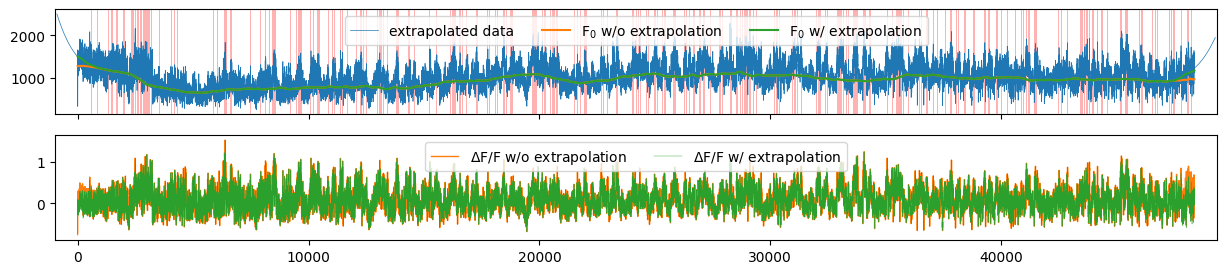

In [58]:
fit_and_plot(traces[0][0], extrapolate_deg=3)